In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import gc


Mounted at /content/drive


In [ ]:
# Load the dataset
file_path = '/content/drive/My Drive/Dataset/tweets.csv'
df = pd.read_csv(file_path, encoding='latin-1', header=None)

# Define column headers
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']

# Check the dataset
print("Dataset Head:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nClass Balance (Sentiment Labels):")
print(df['target'].value_counts())


Dataset Head:
   target          id                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype

In [ ]:
nltk.download('stopwords')

# Text Cleaning Function
def clean_text(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\W', ' ', text)
    text = text.lower()
    return text

# Apply text cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

# Stemming
stemmer = SnowballStemmer("english")
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))

# Check cleaned text
print("\nCleaned Text Sample:")
print(df[['text', 'cleaned_text']].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



Cleaned Text Sample:
                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                        cleaned_text  
0  switchfoot bummer shoulda got david carr third...  
1  upset updat facebook text might cri result sch...  
2  kenichan dive mani time ball manag save 50 res...  
3                    whole bodi feel itchi like fire  
4                      nationwideclass behav mad see  


In [ ]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_features = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Define target labels
y = df['target']

# Train-Test Split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(tfidf_features, y, test_size=0.2, random_state=42)

print("\nTF-IDF Train and Test Shapes:")
print("X_train_tfidf:", X_train_tfidf.shape)
print("X_test_tfidf:", X_test_tfidf.shape)



TF-IDF Train and Test Shapes:
X_train_tfidf: (1280000, 5000)
X_test_tfidf: (320000, 5000)


In [ ]:
# Train Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=20)  # Limit depth to speed up training
dt_classifier.fit(X_train_tfidf, y_train)

print("Decision Tree Classifier trained successfully!")

# Predictions
y_pred = dt_classifier.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree Classifier: {accuracy * 100:.2f}%")


Decision Tree Classifier trained successfully!
Accuracy of the Decision Tree Classifier: 63.57%



Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.36      0.50    159494
           4       0.59      0.91      0.71    160506

    accuracy                           0.64    320000
   macro avg       0.69      0.63      0.61    320000
weighted avg       0.69      0.64      0.61    320000



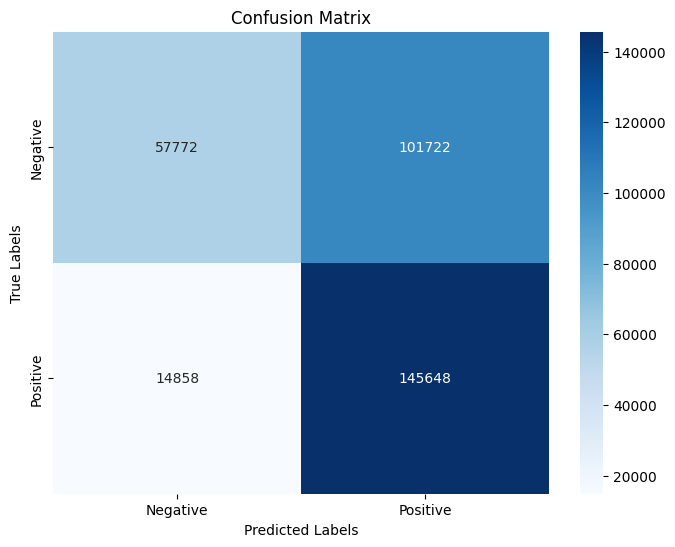

In [ ]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Grid Search
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train_tfidf, y_train)

# Best Parameters
print("Best parameters found: ", grid_search.best_params_)

# Evaluate with the best model
best_dt_classifier = grid_search.best_estimator_
y_pred_tuned = best_dt_classifier.predict(X_test_tfidf)

# Tuned Accuracy
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Decision Tree Accuracy: {tuned_accuracy * 100:.2f}%")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
